# Wireless Backhaul Capacity Workflow

This notebook keeps the workflow notebook-friendly while moving the heavy lifting into a local helper module.

Use it in three steps:
1. Edit the compact parameter block.
2. Run the sweep cell once to generate a reusable results table.
3. Run whichever plot and summary cells you need.

The underlying computation is sweep-first, so the same results table can drive city comparisons, distance studies, multi-band combining, and multi-hop comparisons without editing the modeling code each time.


In [23]:
# Run this once in a fresh runtime if the setup cell fails with a NumPy / astropy / itur import error.
# %pip install -q "numpy<2" "astropy==6.0.1" "itur==0.4.0" seaborn matplotlib pandas scipy
# Then restart the kernel/runtime and rerun the notebook from the top.


In [24]:
import os
from pathlib import Path

workspace_tmp = Path.cwd() / ".mpl_cache"
workspace_tmp.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(workspace_tmp))

import numpy as np

if int(np.__version__.split(".")[0]) >= 2:
    raise RuntimeError(
        "Detected NumPy "
        f"{np.__version__}. This notebook currently needs NumPy < 2 for itur/astropy compatibility. "
        "Run the install cell above, restart the kernel/runtime, and rerun the notebook."
    )

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from wireless_backhaul_analysis import (
    CITY_PRESETS,
    DEFAULT_FREQ_COLORS,
    DEFAULT_FREQ_ORDER,
    build_augmented_band_dataframe,
    build_results_dataframe,
    plot_city_panels,
    plot_multihop_vs_combining_panel,
    plot_single_and_combined_panel,
    select_scenario,
    summarize_capacity_at_outages,
)

sns.set_theme(
    style="whitegrid",
    context="talk",
    rc={"legend.fontsize": 9, "legend.title_fontsize": 9},
)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 50)

SCENARIO_COLS = [
    "city",
    "climate",
    "city_title",
    "rain_label",
    "rain_rate001_mm_per_hr",
    "d_km",
    "per_hop_d_km",
    "bandwidth_mode",
    "N_h",
    "N_p",
]


In [49]:
ANALYSIS_CONFIG = {
    "cities": ["Phoenix", "New York City", "Miami", "Panama City"],
    "distances_km": [5, 6, 10, 25],
    "carrier_freqs_ghz": [6, 11, 18, 23, 39, 80],
    "hops": [1, 2, 3],
    "bandwidth_mode": "diff",
    "ptx_eirp_dBm": 80.0,
    "attenuation_grid_db": np.logspace(-3, 5, 1500),
}

CITY_PLOT_CONFIG = {
    "distance_km": 5,
    "carrier_labels": DEFAULT_FREQ_ORDER,
}

COMBINING_CONFIG = {
    "city": "Miami",
    "distance_km": 6,
    "anchor_panels": {
        "6 GHz": {
            "single_labels": ["6 GHz", "39 GHz", "80 GHz"],
            "combos": [("6 GHz", "39 GHz"), ("6 GHz", "80 GHz")],
        },
        "11 GHz": {
            "single_labels": ["11 GHz", "39 GHz", "80 GHz"],
            "combos": [("11 GHz", "39 GHz"), ("11 GHz", "80 GHz")],
        },
    },
}

MULTIHOP_CONFIG = {
    "city": "Miami",
    "distance_km": 6,
    "hop_values": [1, 2, 3],
    "comparisons": [
        {"target_band": "39 GHz", "combo_label": "11 GHz & 39 GHz", "title": "39 GHz"},
        {"target_band": "80 GHz", "combo_label": "11 GHz & 80 GHz", "title": "80 GHz"},
    ],
}

selected_cities = [CITY_PRESETS[name] for name in ANALYSIS_CONFIG["cities"]]


In [50]:
df = build_results_dataframe(
    cities=selected_cities,
    distances_km=ANALYSIS_CONFIG["distances_km"],
    carrier_freqs_ghz=ANALYSIS_CONFIG["carrier_freqs_ghz"],
    hops=ANALYSIS_CONFIG["hops"],
    attenuation_grid_db=ANALYSIS_CONFIG["attenuation_grid_db"],
    bandwidth_mode=ANALYSIS_CONFIG["bandwidth_mode"],
    ptx_eirp_dBm=ANALYSIS_CONFIG["ptx_eirp_dBm"],
)

print(f"Computed {len(df):,} points across {df['city'].nunique()} cities, {df['d_km'].nunique()} distances, and {df['carrier_label'].nunique()} bands.")
df.head()


Computed 63,585 points across 4 cities, 4 distances, and 6 bands.


,city,climate,city_title,rain_label,lat,lon,h_e,h_r,rain_rate001_mm_per_hr,d_km,per_hop_d_km,carrier_freq_ghz,carrier_label,capacity_gbps,bandwidth_mode,bandwidth_hz,N_h,N_p,A_dB,rain_outage,multipath_outage,p,nines,availability_pct
0,Miami,Tropical,Miami - Tropical,Miami - 78.15 mm/h,25.8,-80.2,25.0,25.0,78.14948,5.0,5.0,6,6 GHz,3.110865,diff,120000000.0,1,1,2.087115,0.000040,0.049095,0.049134,1.308616,95.086584
1,Miami,Tropical,Miami - Tropical,Miami - 78.15 mm/h,25.8,-80.2,25.0,25.0,78.14948,5.0,5.0,6,6 GHz,3.109837,diff,120000000.0,1,1,2.112921,0.000038,0.048010,0.048049,1.318319,95.195142
2,Miami,Tropical,Miami - Tropical,Miami - 78.15 mm/h,25.8,-80.2,25.0,25.0,78.14948,5.0,5.0,6,6 GHz,3.108795,diff,120000000.0,1,1,2.139046,0.000037,0.046937,0.046974,1.328143,95.302606
3,Miami,Tropical,Miami - Tropical,Miami - 78.15 mm/h,25.8,-80.2,25.0,25.0,78.14948,5.0,5.0,6,6 GHz,3.107741,diff,120000000.0,1,1,2.165494,0.000035,0.045875,0.045910,1.338088,95.408953
4,Miami,Tropical,Miami - Tropical,Miami - 78.15 mm/h,25.8,-80.2,25.0,25.0,78.14948,5.0,5.0,6,6 GHz,3.106674,diff,120000000.0,1,1,2.192269,0.000034,0.044824,0.044858,1.348156,95.514161


In [51]:
summary_df = summarize_capacity_at_outages(
    select_scenario(
        df,
        distance_km=CITY_PLOT_CONFIG["distance_km"],
        hops=1,
        bandwidth_mode=ANALYSIS_CONFIG["bandwidth_mode"],
    ),
    group_cols=("city", "carrier_label", "N_h"),
)

summary_df.sort_values(["city", "carrier_label"]).reset_index(drop=True)


,city,carrier_label,N_h,99.000%,99.900%,99.990%,99.999%
0,Miami,11 GHz,1,3.968600,3.805829,3.564764,NaN
1,Miami,18 GHz,1,4.857400,4.548763,3.724671,NaN
2,Miami,23 GHz,1,4.837091,4.408095,3.215447,NaN
3,Miami,39 GHz,1,17.397841,13.732949,4.828136,NaN
4,Miami,6 GHz,1,3.037243,2.931572,2.807857,2.657824
5,Miami,80 GHz,1,39.890850,26.249744,0.423599,NaN
6,New York City,11 GHz,1,4.020975,3.904895,3.762249,3.626114
7,New York City,18 GHz,1,4.938702,4.750483,4.330337,NaN
8,New York City,23 GHz,1,4.929884,4.688514,4.023148,NaN
9,New York City,39 GHz,1,17.917937,15.744381,10.173675,NaN


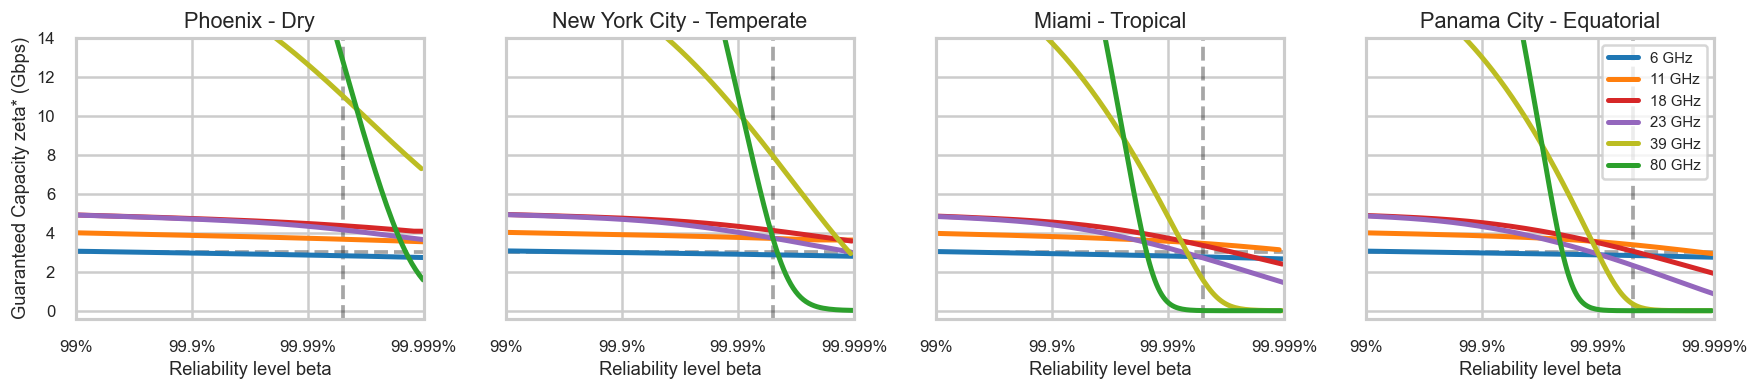

In [52]:
fig, axes = plot_city_panels(
    df=df,
    cities=ANALYSIS_CONFIG["cities"],
    distance_km=CITY_PLOT_CONFIG["distance_km"],
    bandwidth_mode=ANALYSIS_CONFIG["bandwidth_mode"],
    hops=1,
    carrier_labels=CITY_PLOT_CONFIG["carrier_labels"],
    palette=DEFAULT_FREQ_COLORS,
)
plt.show()


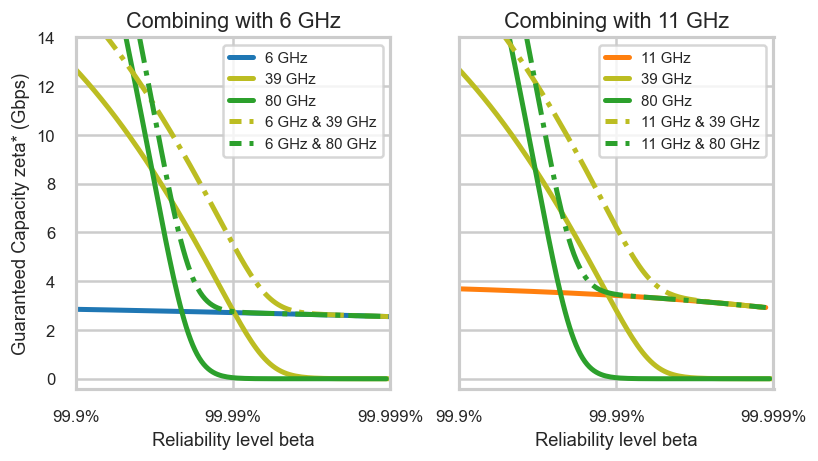

In [53]:
single_hop_df = select_scenario(
    df,
    hops=1,
    bandwidth_mode=ANALYSIS_CONFIG["bandwidth_mode"],
    n_paths=1,
)

combining_frames = {}
for anchor_band, panel_cfg in COMBINING_CONFIG["anchor_panels"].items():
    combining_frames[anchor_band] = build_augmented_band_dataframe(
        df=single_hop_df,
        combos=panel_cfg["combos"],
        keep_single_labels=panel_cfg["single_labels"],
        scenario_cols=SCENARIO_COLS,
    )

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(7.5, 3.8))

plot_single_and_combined_panel(
    ax=axes[0],
    df=combining_frames["6 GHz"],
    city=COMBINING_CONFIG["city"],
    distance_km=COMBINING_CONFIG["distance_km"],
    title="Combining with 6 GHz",
    single_labels=COMBINING_CONFIG["anchor_panels"]["6 GHz"]["single_labels"],
    combined_labels=["6 GHz & 39 GHz", "6 GHz & 80 GHz"],
    bandwidth_mode=ANALYSIS_CONFIG["bandwidth_mode"],
    palette=DEFAULT_FREQ_COLORS,
)

plot_single_and_combined_panel(
    ax=axes[1],
    df=combining_frames["11 GHz"],
    city=COMBINING_CONFIG["city"],
    distance_km=COMBINING_CONFIG["distance_km"],
    title="Combining with 11 GHz",
    single_labels=COMBINING_CONFIG["anchor_panels"]["11 GHz"]["single_labels"],
    combined_labels=["11 GHz & 39 GHz", "11 GHz & 80 GHz"],
    bandwidth_mode=ANALYSIS_CONFIG["bandwidth_mode"],
    palette=DEFAULT_FREQ_COLORS,
)

plt.subplots_adjust(wspace=0.22, hspace=0)
plt.show()


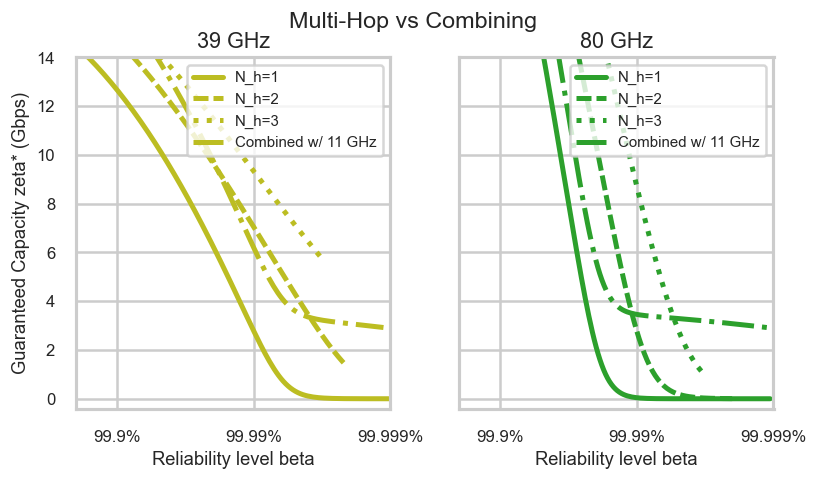

In [54]:
multihop_combined_df = build_augmented_band_dataframe(
    df=single_hop_df,
    combos=[("11 GHz", "39 GHz"), ("11 GHz", "80 GHz")],
    keep_single_labels=["11 GHz", "39 GHz", "80 GHz"],
    scenario_cols=SCENARIO_COLS,
)

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(7.5, 3.8))

for ax, comparison in zip(axes, MULTIHOP_CONFIG["comparisons"]):
    plot_multihop_vs_combining_panel(
        ax=ax,
        base_df=df,
        combined_df=multihop_combined_df,
        city=MULTIHOP_CONFIG["city"],
        distance_km=MULTIHOP_CONFIG["distance_km"],
        target_band=comparison["target_band"],
        combo_label=comparison["combo_label"],
        title=comparison["title"],
        hop_values=MULTIHOP_CONFIG["hop_values"],
        bandwidth_mode=ANALYSIS_CONFIG["bandwidth_mode"],
        palette=DEFAULT_FREQ_COLORS,
    )

legend_elements_left = [
    Line2D([0], [0], color=DEFAULT_FREQ_COLORS["39 GHz"], lw=3, linestyle="-", label="N_h=1"),
    Line2D([0], [0], color=DEFAULT_FREQ_COLORS["39 GHz"], lw=3, linestyle=(0, (3, 1)), label="N_h=2"),
    Line2D([0], [0], color=DEFAULT_FREQ_COLORS["39 GHz"], lw=3, linestyle=":", label="N_h=3"),
    Line2D([0], [0], color=DEFAULT_FREQ_COLORS["11 GHz & 39 GHz"], lw=3, linestyle="-.", label="Combined w/ 11 GHz"),
]
legend_elements_right = [
    Line2D([0], [0], color=DEFAULT_FREQ_COLORS["80 GHz"], lw=3, linestyle="-", label="N_h=1"),
    Line2D([0], [0], color=DEFAULT_FREQ_COLORS["80 GHz"], lw=3, linestyle=(0, (3, 1)), label="N_h=2"),
    Line2D([0], [0], color=DEFAULT_FREQ_COLORS["80 GHz"], lw=3, linestyle=":", label="N_h=3"),
    Line2D([0], [0], color=DEFAULT_FREQ_COLORS["11 GHz & 80 GHz"], lw=3, linestyle="-.", label="Combined w/ 11 GHz"),
]

axes[0].legend(handles=legend_elements_left, loc="upper right", frameon=True, fontsize=9)
axes[1].legend(handles=legend_elements_right, loc="upper right", frameon=True, fontsize=9)
fig.suptitle("Multi-Hop vs Combining", fontsize=14, y=0.98)
plt.subplots_adjust(wspace=0.22, hspace=0)
plt.show()
